<a href="https://colab.research.google.com/github/VHBigCook/MMMvPVS/blob/main/IT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Индивидуальное задание

In [24]:
import numpy as np
from IPython.display import display, Math, Markdown

## Начальные условия

N = 3 - сколько типов процессорв

m_1 = 2 - сколько процов 1 типа

m_2 = 1 - сколько процов 2 типа

m_3 = 1 - сколько процов 3 типа

n = 3 - сколько шин, спсобов передачи даннных

T_о1 = 1.33 - время выполнеия операции процом 1 типа

T_02 = 8

T_03 = 50

Tau_1 = 1.2 - интенсивность обслуживания для 1 проца

Tau_2 = 1.2

Tau_3 = 1.3

q = 0.35 - параметр связанности алгоритма по памяти

In [25]:
N = 3
m1, m2, m3 = 2, 1, 1
n = 3
To1, To2, To3 = 1.33, 8, 50
tau1, tau2, tau3 = 1.2, 1.2, 1.3
q = 0.35

In [26]:
v1 = (q/n) / (To1 - (q/n)*tau1)
v2 = (q/n) / (To2 - (q/n)*tau2)
v3 = (q/n) / (To3 - (q/n)*tau3)
mu1 = 1/tau1
mu2 = 1/tau2
mu3 = 1/tau3

rho1 = v1/mu1
rho2 = v2/mu2
rho3 = v3/mu3

display(Markdown(rf"* $\nu_1 = {v1}$"))
display(Markdown(rf"* $\nu_2 = {v2}$"))
display(Markdown(rf"* $\nu_3 = {v3}$"))
display(Markdown(rf"* $\mu_1 = {mu1}$"))
display(Markdown(rf"* $\mu_2 = {mu2}$"))
display(Markdown(rf"* $\mu_3 = {mu3}$"))

* $\nu_1 = 0.09803921568627448$

* $\nu_2 = 0.014843087362171329$

* $\nu_3 = 0.0023404326456919317$

* $\mu_1 = 0.8333333333333334$

* $\mu_2 = 0.8333333333333334$

* $\mu_3 = 0.7692307692307692$

Проверим условие стационарного режима:

$\forall i: \rho_i = \frac{\nu_i}{\mu_i} \le 1$

In [27]:
ro1 = v1/mu1
ro2 = v2/mu2
ro3 = v3/mu3

In [28]:
display(Markdown(rf"* $\rho_1 = {ro1} \le 1$"))
display(Markdown(rf"* $\rho_2 = {ro2} \le 1$"))
display(Markdown(rf"* $\rho_3 = {ro3} \le 1$"))

* $\rho_1 = 0.11764705882352937 \le 1$

* $\rho_2 = 0.017811704834605594 \le 1$

* $\rho_3 = 0.0030425624393995115 \le 1$

Стационарный режим выполняется.

## Граф состояний

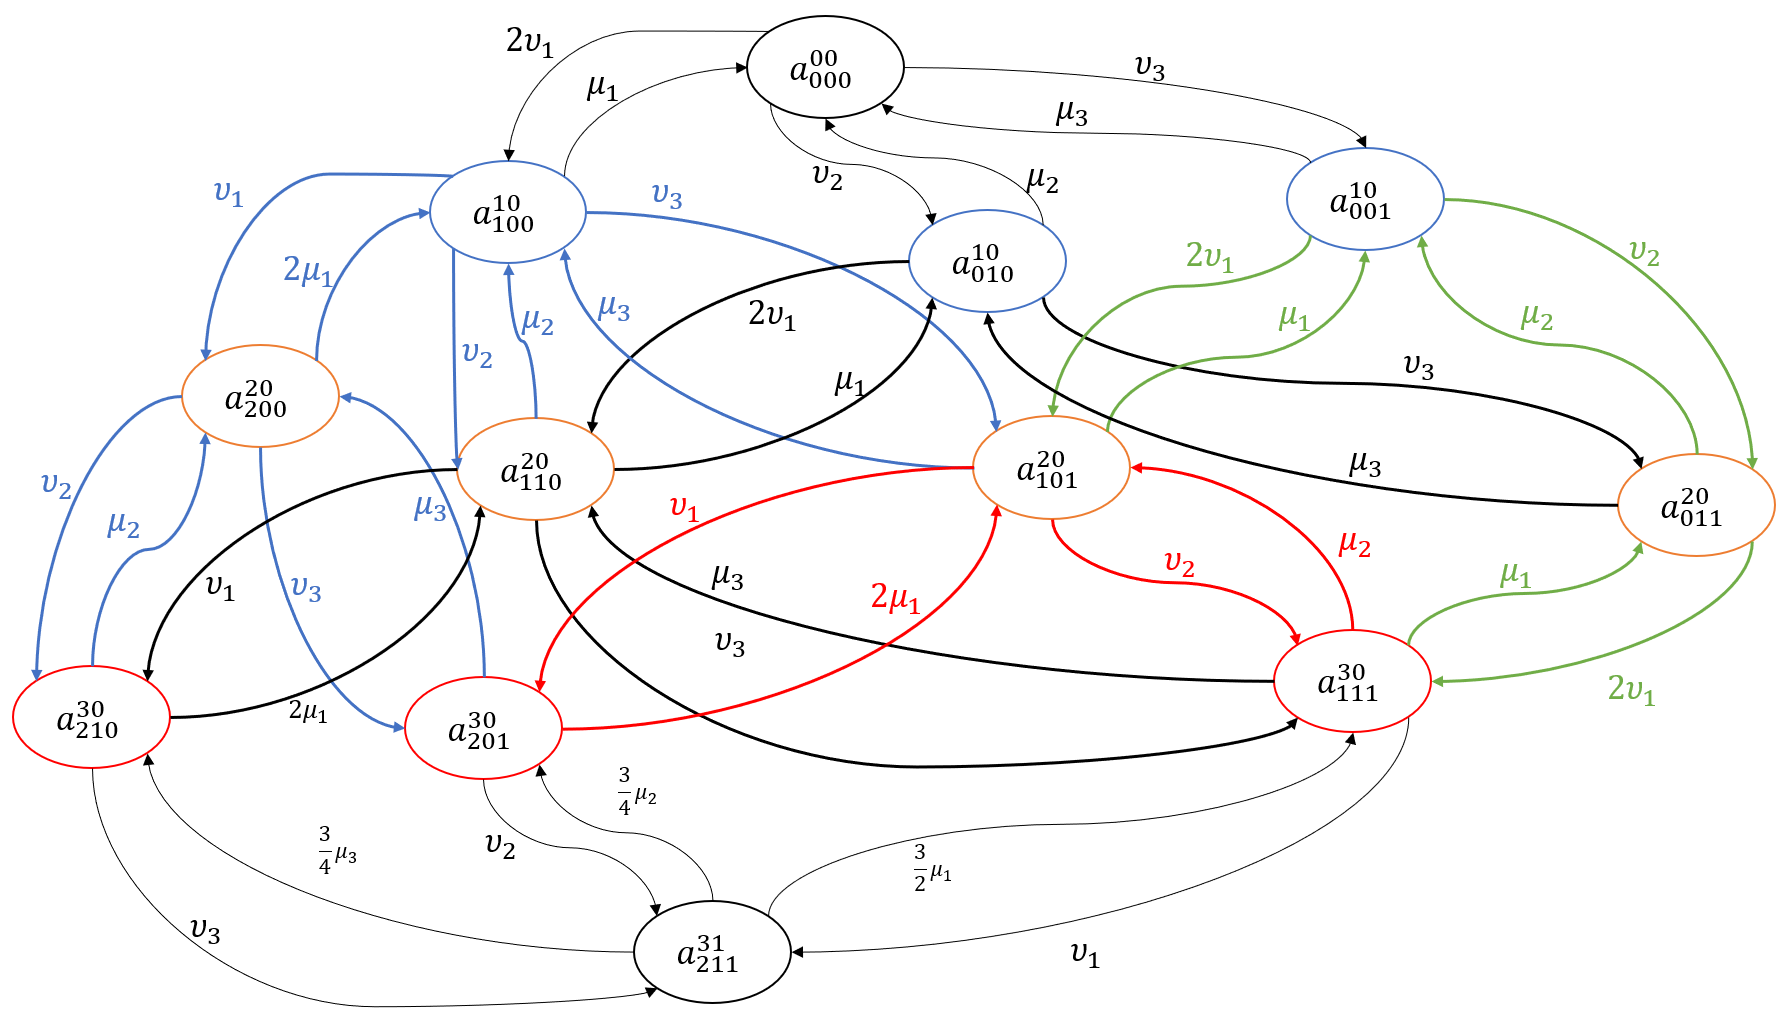


## Решим СЛАУ, найдем вероятности состояний

Система в виде $A \cdot X=B$.

In [29]:
A = [
      [-(2*v1+v2+v3),  mu1,                  mu2,                  mu3,                  0,                         0,                         0,                         0,                         0,                         0,                         0,                         0],
      [2*v1,           -(mu1+v1+v2+v3),      0,                    0,                    2*mu1,                     mu2,                       mu3,                       0,                         0,                         0,                         0,                         0],
      [v2,             0,                    -(mu2+2*v1+v3),       0,                    0,                         mu1,                       0,                         mu3,                       0,                         0,                         0,                         0],
      [v3,             0,                    0,                    -(mu3+2*v1+v2),       0,                         0,                         mu1,                       mu2,                       0,                         0,                         0,                         0],
      [0,              v1,                   0,                    0,                    -(2*mu1+v2+v3),            0,                         0,                         0,                         mu2,                      mu3,                      0,                         0],
      [0,              v2,                   2*v1,                 0,                    0,                         -(mu1+mu2+v1+v3),          0,                         0,                         2*mu1,                    0,                         mu3,                      0],
      [0,              v3,                   0,                    2*v1,                 0,                         0,                         -(mu1+mu3+v1+v2),          0,                         0,                         2*mu1,                    mu2,                      0],
      [0,              0,                    v3,                   v2,                   0,                         0,                         0,                         -(mu2+mu3+2*v1),          0,                         0,                         mu1,                      0],
      [0,              0,                    0,                    0,                    v2,                        v1,                        0,                         0,                         -(2*mu1+mu2+v3),          0,                         0,                         3*mu3/4],
      [0,              0,                    0,                    0,                    v3,                        0,                         v1,                        0,                         0,                         -(2*mu1+mu3+v2),          0,                         3*mu2/4],
      [0,              0,                    0,                    0,                    0,                         v3,                        v2,                        2*v1,                     0,                         0,                         -(mu1+mu2+mu3+v1),        3*mu1/2],
      [0,              0,                    0,                    0,                    0,                         0,                         0,                         0,                         v3,                        v2,                        v1,                        -(3*mu1/2+3*mu2/4+3*mu3/4)]
     ]

In [30]:
A = np.array(A)

In [31]:
np.set_printoptions(linewidth=150)
print(A)

[[-2.13261951e-01  8.33333333e-01  8.33333333e-01  7.69230769e-01  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 1.96078431e-01 -9.48556069e-01  0.00000000e+00  0.00000000e+00  1.66666667e+00  8.33333333e-01  7.69230769e-01  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 1.48430874e-02  0.00000000e+00 -1.03175220e+00  0.00000000e+00  0.00000000e+00  8.33333333e-01  0.00000000e+00  7.69230769e-01  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 2.34043265e-03  0.00000000e+00  0.00000000e+00 -9.80152288e-01  0.00000000e+00  0.00000000e+00  8.33333333e-01  8.33333333e-01  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  9.80392157e-02  0.00000000e+00  0.00000000e+00 -1.68385019e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00  8.33333333e-01
   7.69230769e-01  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+

Одно из уравнений нужно заменить на условие нормировки.

$P_{00}^{00}+P_{10}^{10}+P_{01}^{10}+P_{02}^{20}+P_{11}^{20}+P_{20}^{20}+P_{21}^{30}+P_{12}^{30}+P_{22}^{31} = 1$

In [32]:
# например, заменим 10-е уравнение
eq_num = 9
A[eq_num] = [1,1,1,1,1,1,1,1,1,1,1,1]

In [33]:
print(A)

[[-2.13261951e-01  8.33333333e-01  8.33333333e-01  7.69230769e-01  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 1.96078431e-01 -9.48556069e-01  0.00000000e+00  0.00000000e+00  1.66666667e+00  8.33333333e-01  7.69230769e-01  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 1.48430874e-02  0.00000000e+00 -1.03175220e+00  0.00000000e+00  0.00000000e+00  8.33333333e-01  0.00000000e+00  7.69230769e-01  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 2.34043265e-03  0.00000000e+00  0.00000000e+00 -9.80152288e-01  0.00000000e+00  0.00000000e+00  8.33333333e-01  8.33333333e-01  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  9.80392157e-02  0.00000000e+00  0.00000000e+00 -1.68385019e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00  8.33333333e-01
   7.69230769e-01  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+

In [34]:
B = np.array([0,0,0,0,0,0,0,0,0,0,0,0])
B[eq_num] = 1
print("B =",B)

B = [0 0 0 0 0 0 0 0 0 1 0 0]


Решим уравнение стандартным инструментом из numpy.

In [35]:
P = np.linalg.solve(A,B)

In [36]:
P_names = ['$P_{000}^{00}$', '$P_{100}^{10}$',
  '$P_{010}^{10}$', '$P_{001}^{10}$', '$P_{200}^{20}$',
  '$P_{110}^{20}$', '$P_{101}^{20}$', '$P_{011}^{20}$',
  '$P_{210}^{30}$', '$P_{201}^{30}$', '$P_{111}^{30}$',
  '$P_{211}^{31}$']

In [37]:
for i in range(11):
  display(Markdown(rf"{P_names[i]} = %.6f"%P[i]))

$P_{000}^{00}$ = 0.784158

$P_{100}^{10}$ = 0.184508

$P_{010}^{10}$ = 0.013967

$P_{001}^{10}$ = 0.002386

$P_{200}^{20}$ = 0.010853

...

$P_{101}^{20}$ = 0.000561

$P_{011}^{20}$ = 0.000042

$P_{210}^{30}$ = 0.000193

$P_{201}^{30}$ = 0.000033

$P_{111}^{30}$ = 0.000010

**Проверим Сумму**

In [38]:
a=0
for i in range(11):
  a+=P[i]
print (a)

0.9999992157588488


## Оценка производительности

Совокупные вероятности:

$P_{00} = P_{000}^{00}$

$P_{10} = P_{100}^{10} + P_{010}^{10} + P_{001}^{10}$

$P_{20} = P_{200}^{20} + P_{110}^{20} + P_{101}^{20} + P_{011}^{20}$

$P_{30} = P_{210}^{30} + P_{201}^{30} + P_{111}^{30}$

$P_{31} = P_{211}^{31}$

In [39]:
P00 = P[0]
P10 = P[1]+P[2]+P[3]
P20 = P[4]+P[5]+P[6]+P[7]
P30 = P[8]+P[9]+P[10]
P31 = P[11]

Средняя длина очереди:

$l_{ср} = \sum{l \cdot P_{l,k}}$

$l_{ср} = 0 \cdot P_{0,0} + 0 \cdot P_{1,0} + 0 \cdot P_{2,0} + 0 \cdot P_{3,0} + 1 \cdot P_{3,1}$

In [40]:
l = 0*P00 + 0*P10 + 0*P20 + 0*P30 + 1*P31
display(Markdown(r"$l_{ср}$ = %.6f"%l))

$l_{ср}$ = 0.000001

Относительная потеря производительности:

$ \theta_i = 1 + \frac{l_{ср}\tau_i}{T_{oi}+\tau_i}$

In [41]:
theta1 = 1 + (l*tau1)/(To1+tau1)
theta2 = 1 + (l*tau2)/(To2+tau2)
theta3 = 1 + (l*tau3)/(To1+tau3)
display(Markdown(r"$\theta_1$ = %.8f"%theta1))
display(Markdown(r"$\theta_2$ = %.8f"%theta2))
display(Markdown(r"$\theta_3$ = %.8f"%theta3))

$\theta_1$ = 1.00000037

$\theta_2$ = 1.00000010

$\theta_3$ = 1.00000039

Производительность:

$ П_{ср} = \sum{\frac{m_i}{\theta_i}}$

In [42]:
Performance = m1/theta1 + m2/theta2 + m3/theta3
display(Markdown(r"$П_{ср}$ = %.5f"%Performance))

$П_{ср}$ = 4.00000

In [45]:
import numpy as np
import pandas as pd
from itertools import product
from math import comb, factorial
from IPython.display import display, Markdown

# ============================================================
# Прямое вычисление вероятностей по формуле со слайда
# Для задачи с 3 типами процессоров:
# m1 = 2, m2 = 1, m3 = 1, n = 3
# ============================================================

m_direct = [m1, m2, m3]
n_direct = n
N_direct = len(m_direct)
M_direct = sum(m_direct)
h_direct = min(M_direct, n_direct)

rho_direct = [v1 / mu1, v2 / mu2, v3 / mu3]

# ------------------------------------------------------------
# Вес состояния P_{j1,j2,j3}^{k,l}
#
# Формула:
#
# C(k+l-1, l) * C(n, k) * 1/n^(k+l)
# * (k+l)! / Π(j_i!)
# * Π[ m_i! / (m_i - j_i)! * rho_i^j_i ]
#
# Условие:
# sum(j_i) = k + l
# ------------------------------------------------------------

def terskov_weight(j, k, l, m, n, rho):
    s = sum(j)

    if s == 0:
        return 1.0 if k == 0 and l == 0 else 0.0

    if s != k + l:
        return 0.0

    if k < 1 or k > min(s, n):
        return 0.0

    if l < 0:
        return 0.0

    w = 1.0

    w *= comb(k + l - 1, l)
    w *= comb(n, k)
    w *= 1 / (n ** (k + l))

    w *= factorial(k + l)

    for ji in j:
        w /= factorial(ji)

    for i, ji in enumerate(j):
        w *= factorial(m[i]) / factorial(m[i] - ji)
        w *= rho[i] ** ji

    return w


def p_label(j, k, l):
    lower = "".join(str(x) for x in j)
    return rf"$P_{{{lower}}}^{{{k}{l}}}$"


def graph_label(j):
    s = sum(j)
    h = min(s, n_direct)
    l = s - h
    lower = "".join(str(x) for x in j)
    return rf"$P_{{{lower}}}^{{{h}{l}}}$"


# ============================================================
# 1. Полное пространство состояний по формуле со слайда
# ============================================================

rows = []

rows.append({
    "j": (0, 0, 0),
    "k": 0,
    "l": 0,
    "state": p_label((0, 0, 0), 0, 0),
    "weight": 1.0
})

for k in range(1, h_direct + 1):
    for l in range(0, M_direct - k + 1):
        s = k + l

        for j in product(*[range(mi + 1) for mi in m_direct]):
            if sum(j) == s:
                w = terskov_weight(j, k, l, m_direct, n_direct, rho_direct)

                if w > 0:
                    rows.append({
                        "j": j,
                        "k": k,
                        "l": l,
                        "state": p_label(j, k, l),
                        "weight": w
                    })

df_direct_full = pd.DataFrame(rows)

Z = df_direct_full["weight"].sum()
df_direct_full["P_direct"] = df_direct_full["weight"] / Z

display(Markdown("## Прямое вычисление по формуле со слайда"))
display(df_direct_full.style.format({
    "weight": "{:.12f}",
    "P_direct": "{:.12f}"
}))


# ============================================================
# 2. Агрегация под порядок состояний графа
# ============================================================
# Порядок состояний:
#
# [a000, a100, a010, a001,
#  a200, a110, a101, a011,
#  a210, a201, a111, a211]
# ============================================================

graph_states = [
    (0, 0, 0),
    (1, 0, 0),
    (0, 1, 0),
    (0, 0, 1),
    (2, 0, 0),
    (1, 1, 0),
    (1, 0, 1),
    (0, 1, 1),
    (2, 1, 0),
    (2, 0, 1),
    (1, 1, 1),
    (2, 1, 1)
]

P_direct_agg = []
state_labels = []

for state in graph_states:
    p_sum = df_direct_full.loc[df_direct_full["j"] == state, "P_direct"].sum()
    P_direct_agg.append(p_sum)
    state_labels.append(graph_label(state))

P_direct_agg = np.array(P_direct_agg, dtype=float)

df_direct_agg = pd.DataFrame({
    "state": state_labels,
    "P_direct_aggregated": P_direct_agg
})

display(Markdown("## Агрегированные вероятности для сравнения с графом"))
display(df_direct_agg.style.format({
    "P_direct_aggregated": "{:.12f}"
}))


P_matrix = np.asarray(P, dtype=float).reshape(-1)

comparison = pd.DataFrame({
    "state": state_labels,
    "P_matrix": P_matrix,
    "P_direct_aggregated": P_direct_agg,
    "abs_diff": np.abs(P_matrix - P_direct_agg)
})

display(Markdown("## Сравнение матричного решения и прямой формулы"))
display(comparison.style.format({
    "P_matrix": "{:.12f}",
    "P_direct_aggregated": "{:.12f}",
    "abs_diff": "{:.3e}"
}))

max_diff = np.max(np.abs(P_matrix - P_direct_agg))

display(Markdown(rf"Максимальное расхождение: ${max_diff:.3e}$"))

if max_diff < 1e-10:
    display(Markdown("Решения совпадают с точностью вычислений."))
else:
    display(Markdown(
        "Решения не совпадают. Нужно проверить порядок состояний, матрицу A "
        "или то, что матричная модель и прямая формула используют одну и ту же детализацию состояний."
    ))

## Прямое вычисление по формуле со слайда

,j,k,l,state,weight,P_direct
0,"(0, 0, 0)",0,0,$P_{000}^{00}$,1.000000000000,0.780097715562
1,"(0, 0, 1)",1,0,$P_{001}^{10}$,0.003042562439,0.002373496008
2,"(0, 1, 0)",1,0,$P_{010}^{10}$,0.017811704835,0.013894870252
3,"(1, 0, 0)",1,0,$P_{100}^{10}$,0.235294117647,0.183552403662
4,"(0, 1, 1)",1,1,$P_{011}^{11}$,0.000036128816,0.000028184007
5,"(1, 0, 1)",1,1,$P_{101}^{11}$,0.000477264696,0.000372313099
6,"(1, 1, 0)",1,1,$P_{110}^{11}$,0.002793992915,0.002179587490
7,"(2, 0, 0)",1,1,$P_{200}^{11}$,0.009227220300,0.007198133477
8,"(1, 1, 1)",1,2,$P_{111}^{12}$,0.000008500898,0.000006631531
9,"(2, 0, 1)",1,2,$P_{201}^{12}$,0.000028074394,0.000021900771


## Агрегированные вероятности для сравнения с графом

,state,P_direct_aggregated
0,$P_{000}^{00}$,0.780097715562
1,$P_{100}^{10}$,0.183552403662
2,$P_{010}^{10}$,0.013894870252
3,$P_{001}^{10}$,0.002373496008
4,$P_{200}^{20}$,0.014396266954
5,$P_{110}^{20}$,0.004359174981
6,$P_{101}^{20}$,0.000744626199
7,$P_{011}^{20}$,0.000056368014
8,$P_{210}^{30}$,0.000427370096
9,$P_{201}^{30}$,0.000073002569


## Сравнение матричного решения и прямой формулы

,state,P_matrix,P_direct_aggregated,abs_diff
0,$P_{000}^{00}$,0.784158316479,0.780097715562,4.061e-03
1,$P_{100}^{10}$,0.184507839172,0.183552403662,9.554e-04
2,$P_{010}^{10}$,0.013967196477,0.013894870252,7.233e-05
3,$P_{001}^{10}$,0.002385850640,0.002373496008,1.235e-05
4,$P_{200}^{20}$,0.010853402304,0.014396266954,3.543e-03
5,$P_{110}^{20}$,0.003286399171,0.004359174981,1.073e-03
6,$P_{101}^{20}$,0.000561376621,0.000744626199,1.832e-04
7,$P_{011}^{20}$,0.000042496067,0.000056368014,1.387e-05
8,$P_{210}^{30}$,0.000193317598,0.000427370096,2.341e-04
9,$P_{201}^{30}$,0.000033022154,0.000073002569,3.998e-05


Максимальное расхождение: $4.061e-03$

Решения не совпадают. Нужно проверить порядок состояний, матрицу A или то, что матричная модель и прямая формула используют одну и ту же детализацию состояний.

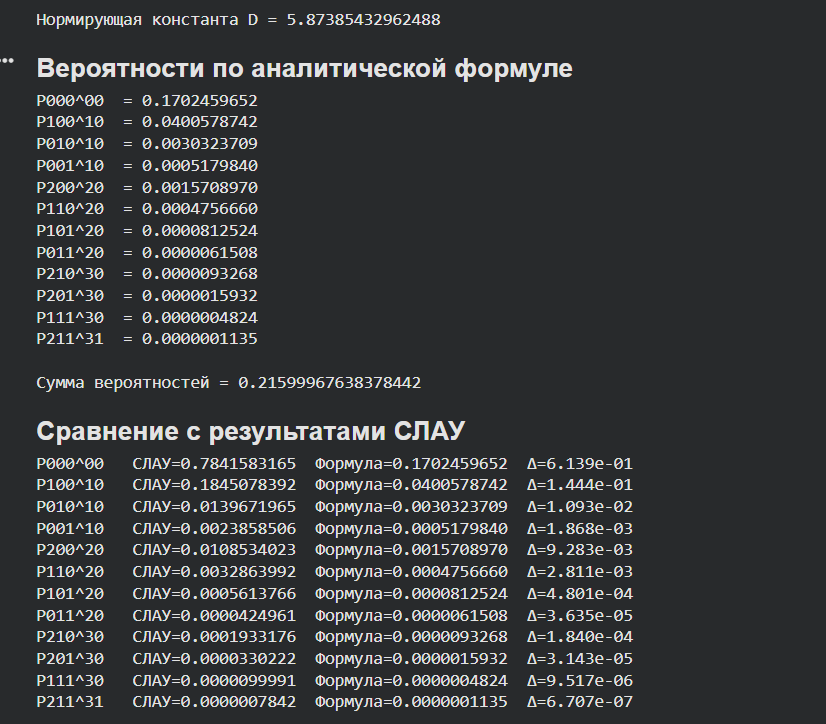